In [1]:
import torch
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_csv("bodyPerformance.csv")

In [3]:
df.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13393 entries, 0 to 13392
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      13393 non-null  float64
 1   gender                   13393 non-null  str    
 2   height_cm                13393 non-null  float64
 3   weight_kg                13393 non-null  float64
 4   body fat_%               13393 non-null  float64
 5   diastolic                13393 non-null  float64
 6   systolic                 13393 non-null  float64
 7   gripForce                13393 non-null  float64
 8   sit and bend forward_cm  13393 non-null  float64
 9   sit-ups counts           13393 non-null  float64
 10  broad jump_cm            13393 non-null  float64
 11  class                    13393 non-null  str    
dtypes: float64(10), str(2)
memory usage: 1.2 MB


In [5]:
df = df.rename(columns={
    "age":"yaş",
    "gender":"cinsiyet",
    "height_cm":"boy",
    "weight_kg":"kilo",
    "body fat_%":"vücut yağ oranı",
    "diastolic":"küçük tansiyon",
    "systolic":"büyük tansiyon",
    "gripForce":"kavrama kuvveti",
    "sit and bend forward_cm":"otur uzan esneklik uzunluğu",
    "sit-ups counts":"mekik sayısı",
    "broad jump_cm":"uzun atlama",
    "class":"fiziksel uygunluk sınıfı"})

In [6]:
df.head()

,yaş,cinsiyet,boy,kilo,vücut yağ oranı,küçük tansiyon,büyük tansiyon,kavrama kuvveti,otur uzan esneklik uzunluğu,mekik sayısı,uzun atlama,fiziksel uygunluk sınıfı
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


In [7]:
df["cinsiyet"] = df["cinsiyet"].map({"M":1,"F":0})

In [8]:
df.head()

,yaş,cinsiyet,boy,kilo,vücut yağ oranı,küçük tansiyon,büyük tansiyon,kavrama kuvveti,otur uzan esneklik uzunluğu,mekik sayısı,uzun atlama,fiziksel uygunluk sınıfı
0,27.0,1,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,1,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,1,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,1,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,1,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


In [9]:
df["fiziksel uygunluk sınıfı"].value_counts()

fiziksel uygunluk sınıfı
C    3349
D    3349
A    3348
B    3347
Name: count, dtype: int64

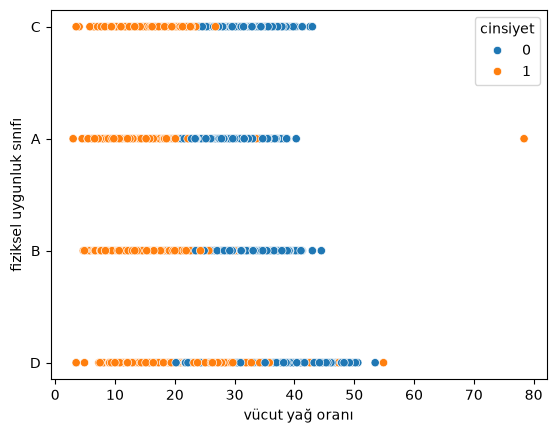

In [10]:
sns.scatterplot(x=df["vücut yağ oranı"], y=df["fiziksel uygunluk sınıfı"], hue=df["cinsiyet"])
plt.show()

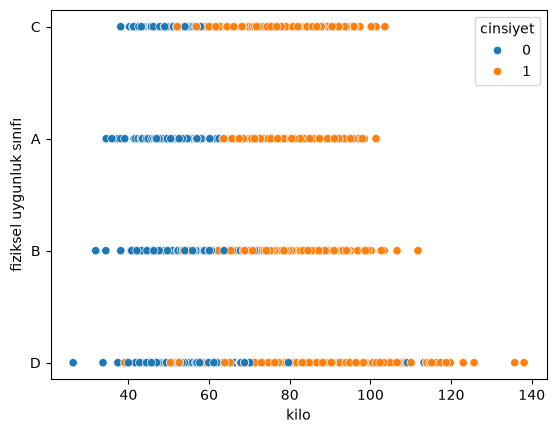

In [11]:
sns.scatterplot(x=df["kilo"], y=df["fiziksel uygunluk sınıfı"], hue=df["cinsiyet"])
plt.show()

In [12]:
X = df.drop("fiziksel uygunluk sınıfı",axis=1).values
y = df["fiziksel uygunluk sınıfı"].values

In [13]:
X

array([[ 27. ,   1. , 172.3, ...,  18.4,  60. , 217. ],
       [ 25. ,   1. , 165. , ...,  16.3,  53. , 229. ],
       [ 31. ,   1. , 179.6, ...,  12. ,  49. , 181. ],
       ...,
       [ 39. ,   1. , 177.2, ...,  16.4,  45. , 229. ],
       [ 64. ,   0. , 146.1, ...,   9.2,   0. ,  75. ],
       [ 34. ,   1. , 164. , ...,   7.1,  51. , 180. ]], shape=(13393, 11))

In [14]:
y

<StringArray>
['C', 'A', 'C', 'B', 'B', 'B', 'D', 'B', 'C', 'B',
 ...
 'B', 'B', 'D', 'D', 'B', 'C', 'D', 'A', 'D', 'C']
Length: 13393, dtype: str

In [15]:
from sklearn.preprocessing import LabelEncoder

In [16]:
le = LabelEncoder()

In [17]:
y = le.fit_transform(y)

In [18]:
y

array([2, 0, 2, ..., 0, 3, 2], shape=(13393,))

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [21]:
y_test

array([3, 3, 2, ..., 1, 0, 3], shape=(2679,))

In [22]:
X_train

array([[ 28. ,   1. , 179.5, ...,  10. ,  50. , 210. ],
       [ 29. ,   1. , 172.7, ...,  19.7,  57. , 254. ],
       [ 39. ,   1. , 177.7, ...,   2.8,  44. , 240. ],
       ...,
       [ 25. ,   1. , 172.6, ...,  17.7,  51. , 255. ],
       [ 39. ,   0. , 160.6, ...,  21.8,  29. , 141. ],
       [ 30. ,   1. , 180. , ...,  17. ,  51. , 264. ]], shape=(10714, 11))

In [23]:
X_train = torch.tensor(X_train,dtype=torch.float32)
X_test = torch.tensor(X_test,dtype=torch.float32)
y_train = torch.tensor(y_train,dtype=torch.long)
y_test = torch.tensor(y_test,dtype=torch.long)

In [24]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

torch.Size([10714, 11]) torch.Size([2679, 11])
torch.Size([10714]) torch.Size([2679])


In [25]:
from torch import nn

In [26]:
class MultiClassClassification(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear_layers = nn.Sequential(
            nn.Linear(11,128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128,256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256,128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128,4)
        )

    def forward(self,x):
        return self.linear_layers(x)

In [27]:
model = MultiClassClassification()

In [28]:
loss_fn = nn.CrossEntropyLoss()

In [29]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

In [30]:
def calculate_accuracy(y_true,y_pred):
    correct = torch.eq(y_true,y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100

    return acc

In [31]:
y_logits=model(X_test)

In [32]:
y_pred_probs = torch.softmax(y_logits,dim=1)

In [33]:
torch.argmax(y_pred_probs[5])

tensor(1)

In [34]:
torch.sum(y_pred_probs[10])

tensor(1., grad_fn=<SumBackward0>)

In [35]:
torch.softmax(y_logits,dim=1).argmax(dim=1)

tensor([0, 1, 1,  ..., 1, 2, 1])

In [36]:
epochs = 300

train_losses = []
test_losses = []
train_accuracy = []
test_accuracy = []

for epoch in range(epochs):

    model.train()

    logits = model(X_train)
    loss = loss_fn(logits,y_train)

    pred = torch.softmax(logits,dim=1).argmax(dim=1)
    acc = calculate_accuracy(y_train,pred)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())
    train_accuracy.append(acc)

    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test)
        test_loss = loss_fn(test_logits,y_test)
        test_pred = torch.softmax(test_logits,dim=1).argmax(dim=1)
        test_acc = calculate_accuracy(y_test,test_pred)
    test_losses.append(test_loss.item())
    test_accuracy.append(test_acc)

    if epoch % 100 == 0:
        print(f"Epoch: {epoch}, Loss: {loss}, Accuracy: {acc}, Test Loss: {test_loss}, Test Accuracy: {test_acc}")

Epoch: 0, Loss: 1.4525798559188843, Accuracy: 25.94735859622923, Test Loss: 1.5287575721740723, Test Accuracy: 25.830533781261668
Epoch: 100, Loss: 0.7622087001800537, Accuracy: 67.15512413664364, Test Loss: 0.755772590637207, Test Accuracy: 67.37588652482269
Epoch: 200, Loss: 0.6747292280197144, Accuracy: 71.78458092215793, Test Loss: 0.6584786176681519, Test Accuracy: 72.93766330720418


In [37]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

In [38]:
print(
    classification_report(
        y_test.numpy(),
        test_pred.numpy()
    )
)

              precision    recall  f1-score   support

           0       0.73      0.83      0.77       670
           1       0.59      0.66      0.62       669
           2       0.73      0.66      0.70       670
           3       0.94      0.78      0.85       670

    accuracy                           0.73      2679
   macro avg       0.75      0.73      0.74      2679
weighted avg       0.75      0.73      0.74      2679



In [39]:
cm = confusion_matrix(y_test.numpy(), test_pred.numpy())

print(cm)

[[554 112   4   0]
 [146 441  70  12]
 [ 51 151 445  23]
 [ 11  46  88 525]]


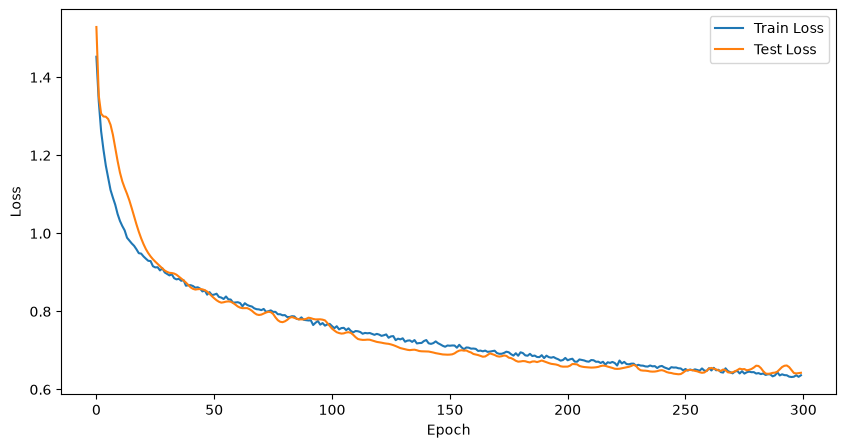

In [40]:
plt.figure(figsize=(10,5))
plt.plot(train_losses, label = "Train Loss")
plt.plot(test_losses, label = "Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

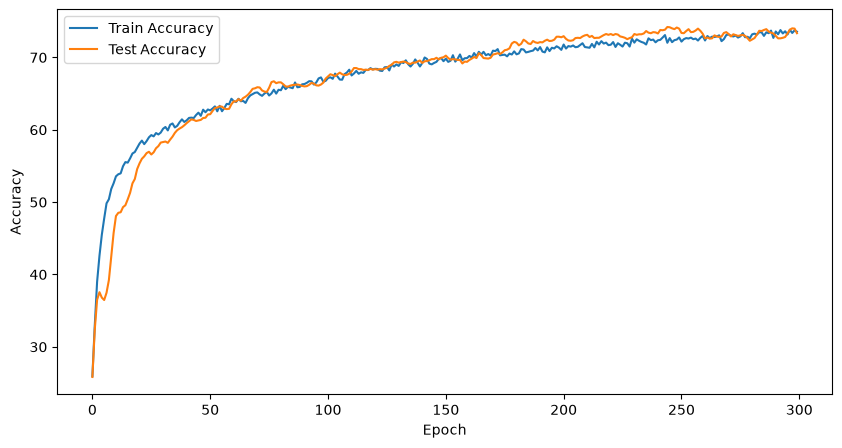

In [41]:
plt.figure(figsize=(10,5))
plt.plot(train_accuracy, label = "Train Accuracy")
plt.plot(test_accuracy, label = "Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [42]:
df.head()

,yaş,cinsiyet,boy,kilo,vücut yağ oranı,küçük tansiyon,büyük tansiyon,kavrama kuvveti,otur uzan esneklik uzunluğu,mekik sayısı,uzun atlama,fiziksel uygunluk sınıfı
0,27.0,1,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,1,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,1,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,1,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,1,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


In [49]:
new_sample = np.array([[16,1,183,84,24,80,150,50,30,60,220]])

In [50]:
new_sample_tensor = torch.tensor(new_sample, dtype=torch.float32)

In [51]:
new_sample_tensor.shape

torch.Size([1, 11])

In [52]:
model.eval()
with torch.inference_mode():
    logits = model(new_sample_tensor)
    probs = torch.softmax(logits,dim=1)
    predicted_class = torch.argmax(probs,dim=1).item()

In [53]:
print(predicted_class)

1


In [54]:
le.inverse_transform([predicted_class])[0]

'B'

In [55]:
from torchmetrics.classification import MulticlassAccuracy

In [56]:
accuracy = MulticlassAccuracy(num_classes=4)

In [57]:
from torchmetrics.classification import MulticlassConfusionMatrix

In [58]:
cm = MulticlassConfusionMatrix(num_classes=4)

In [59]:
matrix = cm(test_pred, y_test)

In [60]:
print(matrix)

tensor([[554, 112,   4,   0],
        [146, 441,  70,  12],
        [ 51, 151, 445,  23],
        [ 11,  46,  88, 525]])


In [61]:
from torchmetrics.utilities.plot import plot_confusion_matrix

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Predicted class', ylabel='True class'>)

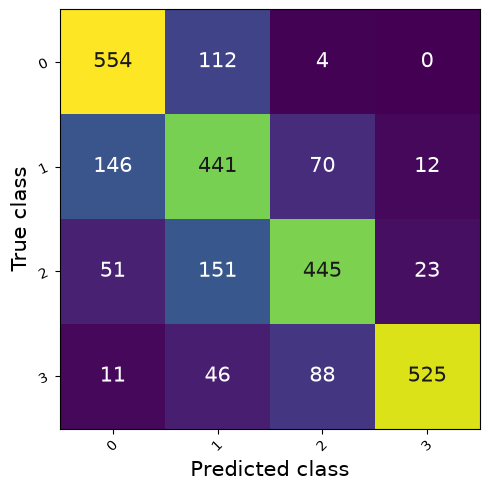

In [62]:
plot_confusion_matrix(matrix)

In [63]:
from pathlib import Path

In [72]:
MODEL_PATH = Path("BoyPerfomanceWebApp")
MODEL_PATH.mkdir(parents=True, exist_ok = True)

MODEL_NAME = "bodyPerformance_classification_model.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

torch.save(obj=model.state_dict(), f= MODEL_SAVE_PATH)

In [73]:
model

MultiClassClassification(
  (linear_layers): Sequential(
    (0): Linear(in_features=11, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=128, out_features=4, bias=True)
  )
)

In [74]:
model.state_dict()

OrderedDict([('linear_layers.0.weight',
              tensor([[ 0.1161, -0.1398,  0.2576,  ..., -0.4200, -0.1323,  0.0543],
                      [ 0.2769, -0.1064,  0.1767,  ...,  0.3236,  0.0634,  0.0377],
                      [ 0.0051, -0.1979, -0.1937,  ...,  0.0372,  0.3043,  0.0734],
                      ...,
                      [ 0.1751, -0.2382, -0.0247,  ..., -0.3961,  0.2467,  0.0114],
                      [-0.1898, -0.0890,  0.1452,  ..., -0.3807,  0.1744, -0.1510],
                      [-0.0542,  0.5601, -0.1621,  ..., -0.1017, -0.3596,  0.1043]])),
             ('linear_layers.0.bias',
              tensor([ 6.5088e-02,  5.4901e-02, -3.1303e-04, -6.9637e-07,  3.2571e-06,
                       8.7784e-08, -2.4405e-02, -5.7536e-03, -4.4207e-03, -4.3061e-02,
                      -3.4888e-02, -4.9931e-02,  2.2297e-02, -9.9960e-08,  4.9986e-02,
                      -4.4248e-07, -2.8462e-02, -1.6598e-03, -4.7807e-03, -4.7186e-08,
                       6.6773e-03,  1.58

In [75]:
loaded_model = MultiClassClassification()

In [76]:
type(torch.load(MODEL_SAVE_PATH))

collections.OrderedDict

In [77]:
loaded_model.load_state_dict(torch.load(MODEL_SAVE_PATH))

<All keys matched successfully>

In [78]:
new_sample = np.array([[16,1,183,84,24,80,150,50,30,60,220]])
new_sample_tensor = torch.tensor(new_sample, dtype=torch.float32)
loaded_model.eval()
with torch.inference_mode():
    logits = loaded_model(new_sample_tensor)
    probs = torch.softmax(logits, dim =1)
    predicted_class = torch.argmax(probs, dim = 1).item()
le.inverse_transform([predicted_class])[0]

'B'

In [79]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13393 entries, 0 to 13392
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   yaş                          13393 non-null  float64
 1   cinsiyet                     13393 non-null  int64  
 2   boy                          13393 non-null  float64
 3   kilo                         13393 non-null  float64
 4   vücut yağ oranı              13393 non-null  float64
 5   küçük tansiyon               13393 non-null  float64
 6   büyük tansiyon               13393 non-null  float64
 7   kavrama kuvveti              13393 non-null  float64
 8   otur uzan esneklik uzunluğu  13393 non-null  float64
 9   mekik sayısı                 13393 non-null  float64
 10  uzun atlama                  13393 non-null  float64
 11  fiziksel uygunluk sınıfı     13393 non-null  str    
dtypes: float64(10), int64(1), str(1)
memory usage: 1.2 MB
